In [1]:
from cases.open_space.preset_configurations import SoundSoft_scattered_field_problem, Penetrable_total_field_problem
R = 1.
r = 0.2
center = (0.2, 0.)

#P = SoundSoft_scattered_field_problem(R=R, r=r)
P = Penetrable_total_field_problem(R=R, r=r, center = center)

P.assemble()

assembling local operators
Boundary: Sigma


Interior: 100%|██████████| 1297/1297 [00:00<00:00, 1402.04edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 16/16 [01:34<00:00,  5.88s/edge]


In [2]:
P.solve()

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

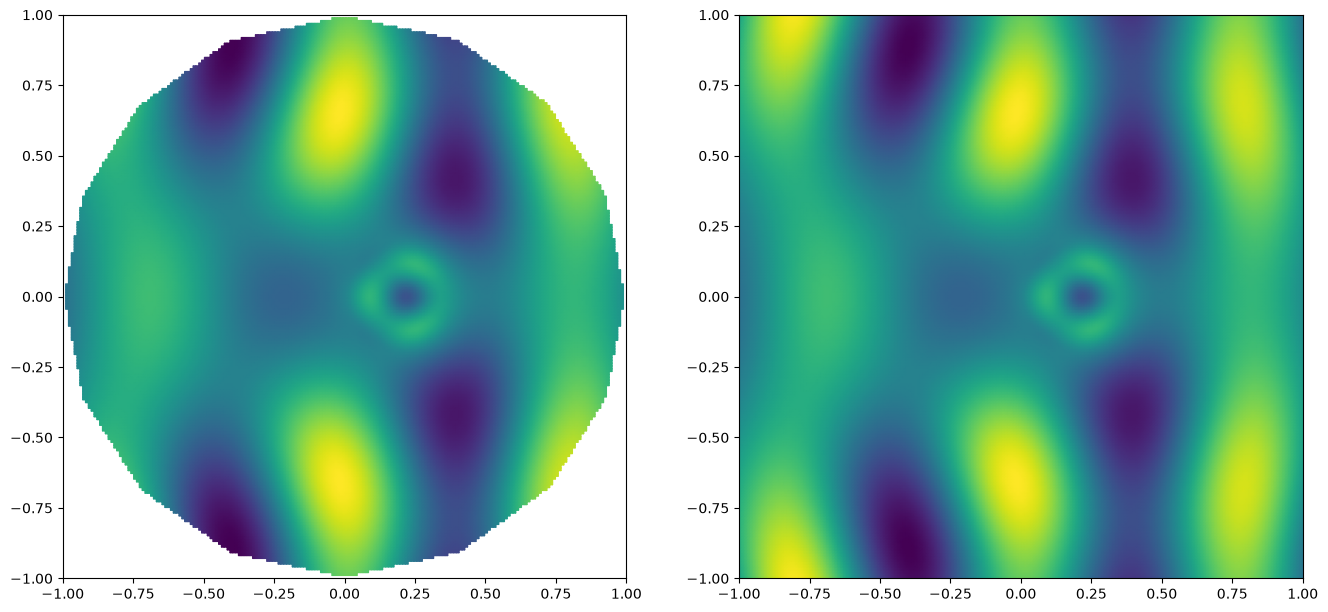

In [3]:
import numpy as np
import matplotlib.pyplot as plt

N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

U_h = P.u_h(X, Y)
U = P.u(X, Y)
fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmin = np.min(U.real)
vmax = np.max(U.real)


ax[0].pcolormesh(X, Y, np.real(U_h), shading="gouraud")
ax[0].axis('square')

ax[1].pcolormesh(X, Y, np.real(U), shading="gouraud")
ax[1].axis('square')


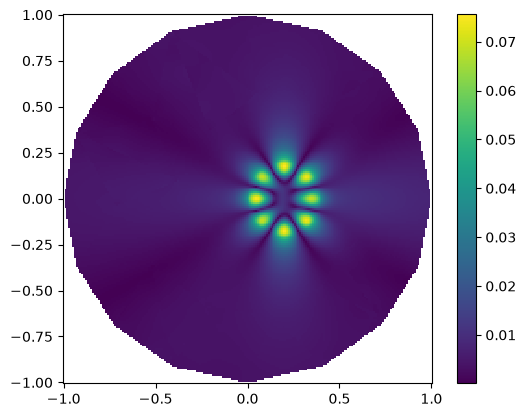

In [5]:
plt.pcolormesh(X, Y, np.abs(U - U_h))
plt.axis('square')
plt.colorbar()

In [4]:
P.u_h.coefficients

array([ 4.30241079e+04+6.17865152e+04j,  1.57864473e+04-7.34909993e+04j,
       -5.63699287e+04+5.04782673e+04j, ...,
       -1.60742010e-02-5.65472261e-02j,  4.21357277e-02-1.55247934e-02j,
       -6.26252892e-02+2.09713867e-02j], shape=(7776,))

In [6]:
from multiprocessing import Pool
from tqdm import tqdm
from trefftz.dg.basis import LinearlySpacedBasis
from trefftz.problem import Problem
from trefftz.mesh import TrefftzMesh
from trefftz.dg.exact import PlaneWave
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal
from trefftz.dg.boundary_conditions import NtDBC
from trefftz.dg.block_fluxes import UltraWeakFlux
from trefftz.dg.assemblers import Numerics
from trefftz.dg.parameters import Elementwise
from cases.open_space.exact import nf_diel_cylinder_plane_wave
from trefftz.dg.assemblers import BlockAssembler
import numpy as np

k = 8.
eps_r = 16.
NtD_modes = 5

def run_theta(args: tuple[TrefftzMesh, int]):
    mesh, N_theta = args
    theta_inc = np.pi
    Boundaries = mesh.boundaries

    d_inc = np.array([np.cos(theta_inc), np.sin(theta_inc)])
    data = PlaneWave(d=d_inc, A=1., k=k)

    a = b = d_2 = 0.5

    eps_r = 16.

    boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=data)}
    numerics = Numerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                            local_boundary_kernels={NtDBC: NtDLocal(d_2=d_2, NtD_modes=NtD_modes, data=data)},
                            nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d_2, NtD_modes=NtD_modes, data = data)})

    Regions = mesh.regions
    refractive_index = Elementwise(mesh, {Regions.BACKGROUND: 1., Regions.OMEGA : np.sqrt(eps_r)})
    basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, refractive_index=refractive_index, k=k, N_theta=N_theta)

    def u_tot(x: float, y: float):
      u_s = nf_diel_cylinder_plane_wave(x, y, k, theta_inc=theta_inc, n=np.sqrt(eps_r), c=np.array([0., 0.]), R=r)
      u_i = np.exp(1j*k*(d_inc[0]*x + d_inc[1]*y))
      RHO = np.sqrt(x**2 + y**2)
      return np.where(RHO<r, u_s, u_s+u_i)


    basis = LinearlySpacedBasis(N_elements=mesh.n_triangles,
                                        k=k,
                                        N_theta=N_theta,
                                        refractive_index=refractive_index)


    problem = Problem(mesh=mesh,
                      wavenumber=k,
                      basis=basis,
                      boundary_conditions=boundary_conditions,
                      assembler=BlockAssembler(),
                      numerics=numerics,
                      direct_solver=True,
                      u=lambda x, y: u_tot(x, y))
    print(f'assembling problem for N_theta = {N_theta}')
    problem.assemble()
    print(f'solving problem for N_theta = {N_theta}')
    problem.solve()
    print(f'computing error for N_theta = {N_theta}')
    error = problem.compute_error_vectorized()

    return problem.u_h, error

In [ ]:
from cases.open_space.ngsolve_geometries import AnularDomain
from trefftz.dg.materials import Dielectric

eps_r =16
R = 1.
r = 0.2
Lc = 2.
lcs = np.logspace(-1,-6,6,base=2)
thetas = range(3,15,2)

N = len(thetas)
Nlc = len(lcs)
center = (0.2, 0.)
errors = np.zeros((Nlc, N))
for i, lc in enumerate(lcs):
     print(f'lc = {lc}')
     Lc = 10*lc
     mesh = AnularDomain(R=R, r=r, center=center, Lc=Lc, lc=lc, scatterer_material=Dielectric(relative_permittivity=eps_r))
     mesh.curve_boundaries([mesh.boundaries.SIGMA], [R])

     args = [(mesh, N_theta) for N_theta in thetas]
     # with Pool(processes=5) as pool:
          
     #     results = list(
     #         tqdm(
     #             pool.imap(run_theta, args),
     #             total=len(args),
     #         )
     #     )


     for j, arg in enumerate(args):
          _, errors[i, j] = run_theta(arg)
          

lc = 0.5
assembling problem for N_theta = 4
assembling local operators
Boundary: Sigma


Interior: 100%|██████████| 124/124 [00:00<00:00, 1836.43edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 16/16 [00:32<00:00,  2.04s/edge]


solving problem for N_theta = 4
computing error for N_theta = 4
assembling problem for N_theta = 6
assembling local operators
Boundary: Sigma


...

solving problem for N_theta = 12
computing error for N_theta = 12
assembling problem for N_theta = 14
assembling local operators
Boundary: Sigma


Interior: 100%|██████████| 3676/3676 [00:03<00:00, 1173.87edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 40/40 [03:26<00:00,  5.16s/edge]


solving problem for N_theta = 14
computing error for N_theta = 14


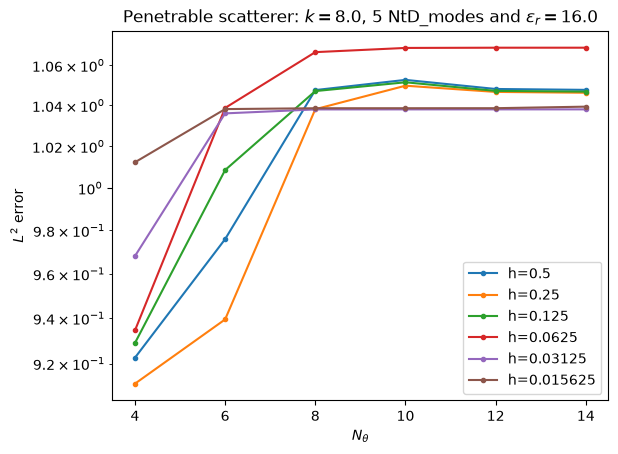

In [ ]:
import matplotlib.pyplot as plt
k = 8.
eps_r = 16.
for error, lc in zip(errors, lcs):
    plt.semilogy(thetas, error, '.-', label=f'h={lc}')
plt.xlabel("$N_\\theta$")
plt.ylabel("$L^2$ error")
plt.legend()
plt.title(f'Penetrable scatterer: $k={k}$, {NtD_modes} NtD_modes and $\\varepsilon_r = {eps_r}$')

plt.savefig(f'L2_error_vs_Ntheta_{NtD_modes}NtD_offcenter.png')

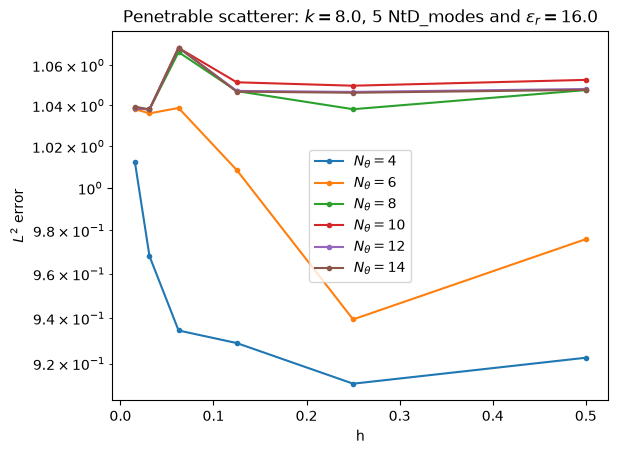

In [ ]:

for error, N_theta in zip(errors.T, thetas):
    plt.semilogy(lcs, error, '.-', label=f'$N_\\theta={N_theta}$')
plt.xlabel("h")
plt.ylabel("$L^2$ error")
plt.legend()
plt.title(f'Penetrable scatterer: $k={k}$, {NtD_modes} NtD_modes and $\\varepsilon_r = {eps_r}$')
plt.savefig(f'L2_error_vs_lc_{NtD_modes}NtD_offcenter.png')


In [ ]:
np.save(f'good_errors{NtD_modes}NtD_offcenter.npy', errors)

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from cases.open_space.ngsolve_geometries import AnularDomain
from trefftz.dg.materials import Dielectric

eps_r =16
R = 1.
r = 0.2

N_theta = 21

lc = 2**-6
Lc = 10*lc

mesh = AnularDomain(R=R, r=r, Lc=Lc, lc=lc, scatterer_material=Dielectric(relative_permittivity=eps_r))
mesh.curve_boundaries([mesh.boundaries.SIGMA], [R])



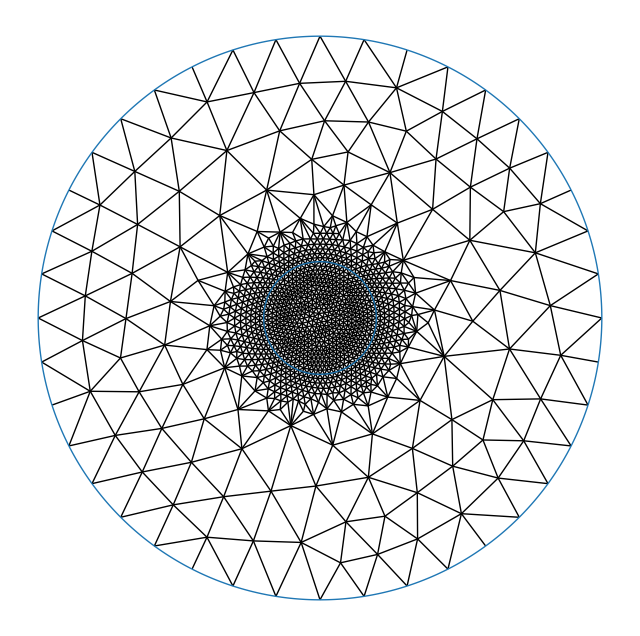

In [14]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [ ]:
k = 8.0
theta_inc = np.pi
Boundaries = mesh.boundaries

d_inc = np.array([np.cos(theta_inc), np.sin(theta_inc)])
data = PlaneWave(d=d_inc, A=1., k=k)
NtD_modes = 15

a = b = d_2 = 0.5

eps_r = 16.

boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=data)}
numerics = Numerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                        local_boundary_kernels={NtDBC: NtDLocal(d_2=d_2, NtD_modes=NtD_modes, data=data)},
                        nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d_2, NtD_modes=NtD_modes, data = data)})

Regions = mesh.regions
refractive_index = Elementwise(mesh, {Regions.BACKGROUND: 1., Regions.OMEGA : np.sqrt(eps_r)})
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, refractive_index=refractive_index, k=k, N_theta=N_theta)

def u_tot(x: float, y: float):
    u_s = nf_diel_cylinder_plane_wave(x, y, k, theta_inc=theta_inc, n=np.sqrt(eps_r), c=np.array([0., 0.]), R=r)
    u_i = np.exp(1j*k*(d_inc[0]*x + d_inc[1]*y))
    RHO = np.sqrt(x**2 + y**2)
    return np.where(RHO<r, u_s, u_s+u_i)


basis = LinearlySpacedBasis(N_elements=mesh.n_triangles,
                                    k=k,
                                    N_theta=N_theta,
                                    refractive_index=refractive_index)


problem = Problem(mesh=mesh,
                    wavenumber=k,
                    basis=basis,
                    boundary_conditions=boundary_conditions,
                    assembler=BlockAssembler(),
                    numerics=numerics,
                    direct_solver=True,
                    u=lambda x, y: u_tot(x, y))
print(f'assembling problem for N_theta = {N_theta}')
problem.assemble()
print(f'solving problem for N_theta = {N_theta}')
problem.solve()
print(f'computing error for N_theta = {N_theta}')
error = problem.compute_error_vectorized()



N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

U_h = problem.u_h(X, Y)
U = problem.u(X, Y)
fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmin = np.min(U.real)
vmax = np.max(U.real)


ax[0].pcolormesh(X, Y, np.real(U_h), shading="gouraud")
ax[0].axis('square')

ax[1].pcolormesh(X, Y, np.real(U), shading="gouraud")
ax[1].axis('square')